#  Рекомендательная система товаров в электронной коммерции

## 1.  Описание проекта

Электронная коммерция является одной из ключевых областей применения рекомендательных систем. Такие системы позволяют пользователям быстрее находить интересующие их товары, а бизнесу — увеличивать вовлечённость и выручку.

В рамках данного проекта решается задача:

> **предсказания товаров, которые с наибольшей вероятностью будут добавлены пользователем в корзину**

Рекомендации строятся на основе пользовательских взаимодействий:

* просмотры (`view`)
* добавления в корзину (`addtocart`)
* покупки (`transaction`)

---

##  Цель проекта

Разработать рекомендательную систему, которая:

* предсказывает товары, интересные пользователю
* учитывает историю взаимодействий
* работает в условиях разреженных данных
* обрабатывает cold start
* может быть развернута как веб-сервис

---

##  Постановка задачи

Задача формулируется как:

> **ranking / recommendation задача с implicit feedback**

Особенности:

* неявная обратная связь (implicit)
* дисбаланс событий (`view >> addtocart >> transaction`)
* временная структура данных
* высокая разреженность user-item матрицы

---

##  Данные

Датасет состоит из трёх источников:

### 1. `events.csv`

Лог пользовательских событий:

* `timestamp` — время события
* `visitorid` — пользователь
* `event` — тип события (`view`, `addtocart`, `transaction`)
* `itemid` — товар
* `transactionid` — id покупки

---

### 2. `category_tree.csv`

* `categoryid` — категория
* `parentid` — родительская категория

---

### 3. `item_properties`

Файл разбит на две части:

* `item_properties_part1.csv`
* `item_properties_part2.csv`

Содержит:

* `timestamp`
* `itemid`
* `property`
* `value`


# 2. Импорты и конфиг

In [1]:
# Стандартная библиотека
import gc
import logging
import os
import pickle
import sys
import warnings
from collections import defaultdict
import joblib
from pathlib import Path
from typing import List, Tuple
import os
import sys
import warnings

# Работа с данными
import numpy as np
import pandas as pd
import polars as pl

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

# Статистика
from scipy.sparse import csr_matrix
from scipy.stats import gaussian_kde
import math

# ML
import mlflow
import lightgbm as lgb
from implicit.als import AlternatingLeastSquares
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Файлы и хранилища
import boto3
import pyarrow as pa
import pyarrow.parquet as pq
import s3fs
from dotenv import load_dotenv

# Прочее
import phik
from phik import report, resources
from tqdm.auto import tqdm

In [2]:
# настройки отображения
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 300)
# отключаем научную нотацию для удобаства анализа данных
pd.options.display.float_format = '{:,.0f}'.format

# настройки графиков
%matplotlib inline
%config InlineBackend.figure_format = "retina"

# корень проекта
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT:", os.path.basename(PROJECT_ROOT))
print("src exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "src")))

def to_relative(path, base):
    try:
        return os.path.relpath(path, base)
    except ValueError:
        return path

from src.utils.config import (
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    EVENTS_PATH,
    CATEGORY_TREE_PATH,
    ITEM_PROPERTIES_PATH_1,
    ITEM_PROPERTIES_PATH_2,
    ARTIFACTS_DIR,
    MODELS_DIR,
    MLFLOW_BASE_DIR,
    MLFLOW_DIR,
    MLFLOW_DB_PATH,
    AIRFLOW_DIR,
    AIRFLOW_DAGS_DIR
)

# S3
S3_BASE = "s3://s3-student-mle-20250927-31ecef0a74/recsys"
S3_DATA_DIR = f"{S3_BASE}/data"
S3_REC_DIR = f"{S3_BASE}/recommendations"

# проверка путей
paths_to_check = {
    "DATA_DIR": DATA_DIR,
    "RAW_DIR": RAW_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "ARTIFACTS_DIR": ARTIFACTS_DIR,
    "MODELS_DIR": MODELS_DIR,
    "MLFLOW_BASE_DIR": MLFLOW_BASE_DIR,
    "MLFLOW_DIR": MLFLOW_DIR,
    "MLFLOW_DB_PATH": MLFLOW_DB_PATH,
    "AIRFLOW_DIR": AIRFLOW_DIR,
    "AIRFLOW_DAGS_DIR": AIRFLOW_DAGS_DIR,
    "EVENTS_PATH": EVENTS_PATH,
    "CATEGORY_TREE_PATH": CATEGORY_TREE_PATH,
    "ITEM_PROPERTIES_PATH_1": ITEM_PROPERTIES_PATH_1,
    "ITEM_PROPERTIES_PATH_2": ITEM_PROPERTIES_PATH_2
}

# mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("ecommerce-recsys")

print("\nProject paths:\n")

for name, path in paths_to_check.items():
    rel_path = to_relative(path, PROJECT_ROOT)
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{name:<22} {rel_path:<40} [{status}]")

2026/04/12 00:15:26 INFO mlflow.tracking.fluent: Experiment with name 'ecommerce-recsys' does not exist. Creating a new experiment.


PROJECT_ROOT: ecommerce-recsys
src exists: True

Project paths:

DATA_DIR               data                                     [OK]
RAW_DIR                data/raw                                 [OK]
PROCESSED_DIR          data/processed                           [OK]
ARTIFACTS_DIR          artifacts                                [OK]
MODELS_DIR             artifacts/models                         [OK]
MLFLOW_BASE_DIR        mlflow                                   [OK]
MLFLOW_DIR             mlflow/mlruns                            [OK]
MLFLOW_DB_PATH         mlflow/mlflow.db                         [OK]
AIRFLOW_DIR            airflow                                  [OK]
AIRFLOW_DAGS_DIR       airflow/dags                             [OK]
EVENTS_PATH            data/raw/events.csv                      [OK]
CATEGORY_TREE_PATH     data/raw/category_tree.csv               [OK]
ITEM_PROPERTIES_PATH_1 data/raw/item_properties_part1.csv       [OK]
ITEM_PROPERTIES_PATH_2 data/raw/item_p

# 3. Загрузка данных

In [3]:
events = pl.read_csv(
    EVENTS_PATH,
    dtypes={
        "visitorid": pl.Int32,
        "event": pl.Categorical,
        "itemid": pl.Int32,
        "transactionid": pl.Float64,
    },
)

category_tree = pl.read_csv(
    f"{CATEGORY_TREE_PATH}",
    dtypes={
        "categoryid": pl.Int32,
        "parentid": pl.Float64,
    },
)

item_props_part1 = pl.read_csv(
    f"{ITEM_PROPERTIES_PATH_1}",
    dtypes={
        "itemid": pl.Int32,
        "property": pl.Categorical,
        "value": pl.Utf8,
    },
)

item_props_part2 = pl.read_csv(
    f"{ITEM_PROPERTIES_PATH_2}",
    dtypes={
        "itemid": pl.Int32,
        "property": pl.Categorical,
        "value": pl.Utf8,
    },
)

item_props = pl.concat([item_props_part1, item_props_part2])

print("Events shape:", events.shape)
print("Category tree shape:", category_tree.shape)
print("Item properties shape:", item_props.shape)

Events shape: (2756101, 5)
Category tree shape: (1669, 2)
Item properties shape: (20275902, 4)


# 3. Предобработка данных

На этом этапе:
- выполняется приведение типов;
- timestamp переводится в datetime;
- из item_properties извлекаются ключевые признаки товаров;
- формируется таблица item-level признаков для дальнейшего моделирования.

## 3.1. Приведение времени и типов

In [4]:
events = events.with_columns(
    [
        pl.from_epoch("timestamp", time_unit="ms").alias("timestamp_dt"),
        pl.col("visitorid").cast(pl.Int32),
        pl.col("itemid").cast(pl.Int32),
        pl.col("event").cast(pl.Categorical),
    ]
)

item_props = item_props.with_columns(
    [
        pl.from_epoch("timestamp", time_unit="ms").alias("timestamp_dt"),
        pl.col("itemid").cast(pl.Int32),
        pl.col("property").cast(pl.Categorical),
    ]
)

category_tree = category_tree.with_columns(
    [
        pl.col("categoryid").cast(pl.Int32),
        pl.col("parentid").cast(pl.Float32, strict=False),
    ]
)

print(events.dtypes)
print(item_props.dtypes)
print(category_tree.dtypes)

[Int64, Int32, Categorical, Int32, Float64, Datetime(time_unit='us', time_zone=None)]
[Int64, Int32, Categorical, String, Datetime(time_unit='us', time_zone=None)]
[Int32, Float32]


## 3.2. Удаление обрезанного хвоста

In [5]:
CUTOFF_DATE = pl.datetime(2015, 9, 15)

events = events.filter(pl.col("timestamp_dt") < CUTOFF_DATE)
item_props = item_props.filter(pl.col("timestamp_dt") < CUTOFF_DATE)

print("events shape after cutoff:", events.shape)
print("item_props shape after cutoff:", item_props.shape)

events shape after cutoff: (2712523, 6)
item_props shape after cutoff: (20275902, 5)


## 3.3. Извлечение available

In [6]:
available_df = (
    item_props.filter(pl.col("property") == "available")
    .with_columns(pl.col("value").cast(pl.Float64, strict=False).alias("value_num"))
    .drop_nulls("value_num")
    .sort(["itemid", "timestamp_dt"])
    .group_by("itemid")
    .tail(1)
    .select([pl.col("itemid"), pl.col("value_num").cast(pl.Int8).alias("available")])
)

## 3.4. Извлечение categoryid

In [7]:
category_df = (
    item_props.filter(pl.col("property") == "categoryid")
    .with_columns(pl.col("value").cast(pl.Float64, strict=False))
    .drop_nulls("value")
    .sort("timestamp_dt")
    .group_by("itemid")
    .agg(pl.col("value").last())
    .with_columns(pl.col("value").cast(pl.Int32).alias("categoryid"))
    .select(["itemid", "categoryid"])
)

category_df.head()

itemid,categoryid
i32,i32
140921,1250
450395,635
405721,637
425094,1197
277108,184


## 3.5. Агрегация базовых item-features

Сразу делаем простые признаки по свойствам товара.

In [8]:
item_prop_counts = (
    item_props.group_by("itemid").len().rename({"len": "item_prop_count"})
)

item_unique_props = item_props.group_by("itemid").agg(
    pl.col("property").n_unique().alias("item_unique_prop_count")
)

item_features = (
    item_prop_counts.join(item_unique_props, on="itemid", how="full")
    .join(available_df, on="itemid", how="left")
    .join(category_df, on="itemid", how="left")
    .with_columns(pl.col("available").fill_null(0).cast(pl.Int8))
    .sort("itemid")
)

item_features.head()

itemid,item_prop_count,itemid_right,item_unique_prop_count,available,categoryid
i32,u32,i32,u32,i8,i32
0,45,0,28,0,209
1,86,1,35,0,1114
2,24,2,24,0,1305
3,46,3,29,0,1171
4,42,4,25,0,1038


## 3.6. Присоединение родительской категории

In [9]:
item_features = item_features.join(
    category_tree.rename({"parentid": "parent_categoryid"}),
    on="categoryid",
    how="left",
)

item_features.head()

itemid,item_prop_count,itemid_right,item_unique_prop_count,available,categoryid,parent_categoryid
i32,u32,i32,u32,i8,i32,f32
0,45,0,28,0,209,293.0
1,86,1,35,0,1114,113.0
2,24,2,24,0,1305,1214.0
3,46,3,29,0,1171,938.0
4,42,4,25,0,1038,1174.0


## 3.7. Фильтрация недоступных товаров

На этапе исследования модели можно сохранить оба варианта:

полный каталог
каталог для рекомендаций

In [10]:
available_count = item_features.filter(pl.col("available") == 1).height

total_items = item_features.select(pl.col("itemid").n_unique()).item()

print("Available items:", available_count)
print("Share of available items:", available_count / total_items)

Available items: 54010
Share of available items: 0.1295039239617027


## 3.8. Сохраняем промежуточные артефакты

In [11]:
# Определяем корень проекта
PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Директория для сохранения
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Пути к файлам
item_features_path = PROCESSED_DIR / "item_features_base.parquet"
events_path = PROCESSED_DIR / "events_preprocessed.parquet"

# Сохранение
item_features.write_parquet(item_features_path)
events.write_parquet(events_path)


# Безопасный вывод относительного пути
def rel_path(path, root):
    try:
        return path.relative_to(root)
    except ValueError:
        return path


print(f"Saved item_features -> {rel_path(item_features_path, PROJECT_ROOT)}")
print(f"Saved events -> {rel_path(events_path, PROJECT_ROOT)}")

Saved item_features -> data/processed/item_features_base.parquet
Saved events -> data/processed/events_preprocessed.parquet


## Выводы по предобработке данных

В рамках предобработки были выполнены следующие шаги:

* временные признаки (`timestamp`) приведены к формату `datetime`;
* удалён неполный хвост данных для исключения искажений в распределениях;
* из `item_properties` извлечены ключевые признаки товаров:

  * `available` — доступность товара;
  * `categoryid` — категория товара;
* построена агрегированная таблица `item_features`, включающая:

  * количество свойств товара;
  * число уникальных свойств;
  * категорию и родительскую категорию;
  * признак доступности товара.

В результате получена базовая таблица признаков товаров, которая будет использоваться на следующих этапах:

* генерация кандидатов;
* построение признаков;
* ранжирование.

---

## Использование Polars

Для этапа предобработки использовалась библиотека **Polars**, что обусловлено следующими причинами:

* высокая скорость обработки данных по сравнению с pandas;
* эффективное использование памяти;
* удобный декларативный API для операций:

  * фильтрации;
  * агрегации (`group_by`);
  * соединений (`join`);
  * преобразования типов.

Polars особенно эффективен на этапах:

* загрузки данных;
* агрегаций;
* feature engineering.

При этом для этапа моделирования (обучение LightGBM, ALS) возможно использование pandas, так как большинство ML-библиотек работают с ним напрямую.

---

## Итог

Предобработка выполнена с учётом:

* предотвращения утечек данных;
* подготовки данных к задаче ранжирования;
* оптимизации вычислений.

Полученные данные готовы к следующему этапу — **разделению по времени и формированию таргета**.


# 4. Time-based split

Для корректной оценки рекомендательной системы используется разбиение по времени.

Это позволяет:
- исключить утечку будущей информации;
- приблизить offline-оценку к реальному production-сценарию;
- обучать модель только на прошлых событиях.

## 4.1. Смотрим временной диапазон

In [12]:
events.select(
    [
        pl.col("timestamp_dt").min().alias("min_timestamp"),
        pl.col("timestamp_dt").max().alias("max_timestamp"),
    ]
)

min_timestamp,max_timestamp
datetime[μs],datetime[μs]
2015-05-03 03:00:04.384,2015-09-14 23:59:45.566


## 4.2. Задаём границы сплитов

Для первого рабочего варианта предлагаю так:

train_end = 2015-08-15
valid_end = 2015-09-01
test = всё после valid_end до CUTOFF_DATE

Это даёт:

длинный train
отдельное validation окно
честный test

In [13]:
TRAIN_END = pl.datetime(2015, 8, 15)
VALID_END = pl.datetime(2015, 9, 1)
TEST_END = pl.datetime(2015, 9, 15)

## 4.3. Делаем сплиты

In [14]:
train_events = events.filter(pl.col("timestamp_dt") < TRAIN_END)

valid_events = events.filter(
    (pl.col("timestamp_dt") >= TRAIN_END) & (pl.col("timestamp_dt") < VALID_END)
)

test_events = events.filter(
    (pl.col("timestamp_dt") >= VALID_END) & (pl.col("timestamp_dt") < TEST_END)
)

print("train_events shape:", train_events.shape)
print("valid_events shape:", valid_events.shape)
print("test_events shape:", test_events.shape)

train_events shape: (2151115, 6)
valid_events shape: (301276, 6)
test_events shape: (260132, 6)


## 4.4. Проверяем диапазоны по каждому сплиту

In [15]:
def show_time_range(df, name):
    summary = df.select(
        [
            pl.col("timestamp_dt").min().alias("min_timestamp"),
            pl.col("timestamp_dt").max().alias("max_timestamp"),
            pl.len().alias("n_rows"),
        ]
    )
    print(f"\n{name}")
    print(summary)


show_time_range(train_events, "train")
show_time_range(valid_events, "valid")
show_time_range(test_events, "test")


train
shape: (1, 3)
┌─────────────────────────┬─────────────────────────┬─────────┐
│ min_timestamp           ┆ max_timestamp           ┆ n_rows  │
│ ---                     ┆ ---                     ┆ ---     │
│ datetime[μs]            ┆ datetime[μs]            ┆ u32     │
╞═════════════════════════╪═════════════════════════╪═════════╡
│ 2015-05-03 03:00:04.384 ┆ 2015-08-14 23:59:56.673 ┆ 2151115 │
└─────────────────────────┴─────────────────────────┴─────────┘

valid
shape: (1, 3)
┌─────────────────────────┬─────────────────────────┬────────┐
│ min_timestamp           ┆ max_timestamp           ┆ n_rows │
│ ---                     ┆ ---                     ┆ ---    │
│ datetime[μs]            ┆ datetime[μs]            ┆ u32    │
╞═════════════════════════╪═════════════════════════╪════════╡
│ 2015-08-15 00:00:07.484 ┆ 2015-08-31 23:59:58.647 ┆ 301276 │
└─────────────────────────┴─────────────────────────┴────────┘

test
shape: (1, 3)
┌─────────────────────────┬──────────────────────

## 4.5. Проверяем распределение событий по сплитам

Это важно, чтобы не получить, например, test без transaction или с перекошенной структурой.

In [16]:
def event_distribution(df, name):
    print(f"\n{name}")
    print(df.group_by("event").len().sort("len", descending=True))


event_distribution(train_events, "train")
event_distribution(valid_events, "valid")
event_distribution(test_events, "test")


train
shape: (3, 2)
┌─────────────┬─────────┐
│ event       ┆ len     │
│ ---         ┆ ---     │
│ cat         ┆ u32     │
╞═════════════╪═════════╡
│ view        ┆ 2080131 │
│ addtocart   ┆ 53529   │
│ transaction ┆ 17455   │
└─────────────┴─────────┘

valid
shape: (3, 2)
┌─────────────┬────────┐
│ event       ┆ len    │
│ ---         ┆ ---    │
│ cat         ┆ u32    │
╞═════════════╪════════╡
│ view        ┆ 290521 │
│ addtocart   ┆ 8122   │
│ transaction ┆ 2633   │
└─────────────┴────────┘

test
shape: (3, 2)
┌─────────────┬────────┐
│ event       ┆ len    │
│ ---         ┆ ---    │
│ cat         ┆ u32    │
╞═════════════╪════════╡
│ view        ┆ 251655 │
│ addtocart   ┆ 6463   │
│ transaction ┆ 2014   │
└─────────────┴────────┘


## 4.6. Проверяем число пользователей и товаров в каждом сплите

In [17]:
def split_stats(df, name):
    stats = df.select(
        [
            pl.len().alias("n_events"),
            pl.col("visitorid").n_unique().alias("n_users"),
            pl.col("itemid").n_unique().alias("n_items"),
        ]
    )
    print(f"\n{name}")
    print(stats)


split_stats(train_events, "train")
split_stats(valid_events, "valid")
split_stats(test_events, "test")


train
shape: (1, 3)
┌──────────┬─────────┬─────────┐
│ n_events ┆ n_users ┆ n_items │
│ ---      ┆ ---     ┆ ---     │
│ u32      ┆ u32     ┆ u32     │
╞══════════╪═════════╪═════════╡
│ 2151115  ┆ 1095383 ┆ 210687  │
└──────────┴─────────┴─────────┘

valid
shape: (1, 3)
┌──────────┬─────────┬─────────┐
│ n_events ┆ n_users ┆ n_items │
│ ---      ┆ ---     ┆ ---     │
│ u32      ┆ u32     ┆ u32     │
╞══════════╪═════════╪═════════╡
│ 301276   ┆ 171295  ┆ 81446   │
└──────────┴─────────┴─────────┘

test
shape: (1, 3)
┌──────────┬─────────┬─────────┐
│ n_events ┆ n_users ┆ n_items │
│ ---      ┆ ---     ┆ ---     │
│ u32      ┆ u32     ┆ u32     │
╞══════════╪═════════╪═════════╡
│ 260132   ┆ 150026  ┆ 75390   │
└──────────┴─────────┴─────────┘


## 4.7. Сохраняем сплиты

In [18]:
train_events_path = PROCESSED_DIR / "train_events.parquet"
valid_events_path = PROCESSED_DIR / "valid_events.parquet"
test_events_path = PROCESSED_DIR / "test_events.parquet"

train_events.write_parquet(train_events_path)
valid_events.write_parquet(valid_events_path)
test_events.write_parquet(test_events_path)

print(f"Saved train_events -> {train_events_path.relative_to(PROJECT_ROOT)}")
print(f"Saved valid_events -> {valid_events_path.relative_to(PROJECT_ROOT)}")
print(f"Saved test_events -> {test_events_path.relative_to(PROJECT_ROOT)}")

Saved train_events -> data/processed/train_events.parquet
Saved valid_events -> data/processed/valid_events.parquet
Saved test_events -> data/processed/test_events.parquet


### Выводы по time-based split

Данные разделены по времени на train, validation и test.

Такое разбиение:
- исключает использование будущих событий при обучении;
- соответствует реальному сценарию работы рекомендательной системы;
- позволяет корректно оценивать качество модели на новых данных.

Дальнейшее формирование таргета и признаков будет выполняться отдельно для каждого временного окна.

# 5. Формирование таргета

Таргет формируется на уровне пар (user, item).

Для каждого пользователя и товара:
- 1 — если пользователь добавил товар в корзину в будущем окне;
- 0 — иначе.

Используется временное разделение:
- история (features)
- будущее окно (target)

Это позволяет избежать утечки данных и приближает модель к реальному сценарию.

## 5.1. Определяем target события
используем:

* addtocart = основной таргет

* transaction можно тоже включить

In [19]:
TARGET_EVENTS = ["addtocart", "transaction"]

## 5.2. Формируем target для validation
делаем для valid (потом аналогично test)

In [20]:
valid_target = (
    valid_events.filter(pl.col("event").is_in(TARGET_EVENTS))
    .select(["visitorid", "itemid"])
    .unique()
    .with_columns(pl.lit(1).alias("target"))
)

valid_target.head()

visitorid,itemid,target
i32,i32,i32
930965,243944,1
1250835,442725,1
1001263,149724,1
481437,380494,1
149737,330481,1


## 5.3. Формируем кандидатов (простая версия)

Пока делаем простой вариант:

* берём товары, которые пользователь видел в train

In [21]:
train_user_items = (
    train_events
    .select(["visitorid", "itemid"])
    .unique()
)

## 5.4. Собираем user-item dataset

In [22]:
valid_dataset = (
    train_user_items
    .join(valid_target, on=["visitorid", "itemid"], how="left")
    .with_columns(
        pl.col("target").fill_null(0).cast(pl.Int8)
    )
)

valid_dataset.head()

visitorid,itemid,target
i32,i32,i8
668549,203248,0
290184,270224,0
1181124,64634,0
646450,339661,0
133873,224355,0


## 5.5. Баланс классов (очень важно)

In [23]:
valid_dataset.select(
    [
        pl.len().alias("n_samples"),
        pl.col("target").sum().alias("positives"),
        (pl.col("target").sum() / pl.len()).alias("positive_rate"),
    ]
)

n_samples,positives,positive_rate
u32,i64,f64
1670835,261,0.000156


## Выводы по таргету и user-item dataset

### 1. Экстремальный дисбаланс классов

* доля позитивов: **~0.015%**
* 261 позитив на ~1.67 млн пар

* задача **очень разреженная и сложная**

---

### 2. Implicit feedback

* отсутствие `addtocart` ≠ негатив
* большинство нулей — это:

  * либо не видел
  * либо не заинтересовался

* классический implicit scenario

---

### 3. Ограниченное пространство кандидатов

* кандидаты = товары из train (исторические взаимодействия)
* нет новых товаров

* модель пока **не умеет рекомендовать новое**

---

### 4. Сильный сигнал таргета

* `addtocart` / `transaction` = высокое намерение
* это правильный выбор target

* хорошая постановка задачи

---

### 5. Датасет готов для ранжирования

* есть `(user, item, target)`
* есть temporal split
* нет leakage

* можно обучать:

* LightGBM ranker
* logistic baseline
* ALS + rerank

---

## Главный вывод

* текущая постановка:

```text
extreme imbalance + implicit feedback + sparse matrix
```

Это означает:

* accuracy бесполезна 
* нужен ranking подход 
* критичен candidate generation

---

## Что это означает для следующих шагов

Обязательно:

* negative sampling
* расширение кандидатов (ALS / popular)
* ranking модель (не классификация)

---

##  Самое важное

* сейчас главный bottleneck — **не модель, а кандидаты**

# 6. Candidate Generation

Для снижения размерности задачи ранжирования используется этап генерации кандидатов.

Цель:
- сократить пространство товаров;
- оставить только наиболее релевантные кандидаты;
- повысить эффективность и качество модели.

Кандидаты генерируются несколькими методами и затем объединяются.

## 6.1. Top Popular (baseline)

In [24]:
TOP_K = 50

popular_items = (
    train_events.group_by("itemid")
    .len()
    .sort("len", descending=True)
    .head(TOP_K)
    .select("itemid")
    .to_series()
    .to_list()
)

popular_items[:10]

[5411, 461686, 309778, 370653, 257040, 187946, 298009, 335975, 96924, 7943]

In [25]:
# Генерим кандидатов для valid
valid_users = valid_events.select("visitorid").unique()

popular_candidates = valid_users.with_columns(
    pl.lit(popular_items).alias("itemid")
).explode("itemid")

## 6.2. User history кандидаты
то, что пользователь уже смотрел

In [26]:
user_history_candidates = train_events.select(["visitorid", "itemid"]).unique()

## 6.3. Объединяем кандидатов

In [27]:
def cast_ids(df):
    return df.with_columns(
        [
            pl.col("visitorid").cast(pl.Int32),
            pl.col("itemid").cast(pl.Int32),
        ]
    )

popular_candidates = cast_ids(popular_candidates)
user_history_candidates = cast_ids(user_history_candidates)
candidates = pl.concat([popular_candidates, user_history_candidates]).unique()
candidates.head()

visitorid,itemid
i32,i32
1078646,17478
1099328,151444
427866,241555
193671,350629
816546,102306


## 6.4. Сколько кандидатов на пользователя

In [28]:
candidates.group_by("visitorid").len().select(
    [
        pl.col("len").mean().alias("avg_candidates"),
        pl.col("len").min().alias("min_candidates"),
        pl.col("len").max().alias("max_candidates"),
    ]
)

avg_candidates,min_candidates,max_candidates
f64,u32,u32
8.182051,1,3111


## 6.5. Добавляем таргет

In [29]:
valid_dataset = candidates.join(
    valid_target, on=["visitorid", "itemid"], how="left"
).with_columns(pl.col("target").fill_null(0).cast(pl.Int8))

## 6.6. Проверка качества кандидатов
покрытие таргета

In [30]:
recall_check = valid_target.join(candidates, on=["visitorid", "itemid"], how="inner")

recall = recall_check.height / valid_target.height

print("Candidate Recall:", recall)

Candidate Recall: 0.06774572510116172


## 6.7 Посчитаем метрики для Top Popular (baseline)

In [31]:
def evaluate_recommendations(actual_map, pred_map, k=10):
    """
    Рассчитывает ranking-метрики по словарям actual/predicted.

    Параметры
    ----------
    actual_map : dict
        Словарь формата {visitorid: [relevant_itemid, ...]}.
    pred_map : dict
        Словарь формата {visitorid: [predicted_itemid_1, predicted_itemid_2, ...]}.
    k : int, default=10
        Глубина списка рекомендаций.

    Возвращает
    ----------
    dict
        Словарь с метриками:
        - Recall@K
        - MAP@K
        - NDCG@K
        - HitRate@K
    """
    common_users = sorted(set(actual_map) & set(pred_map))

    if not common_users:
        return {
            f"Recall@{k}": 0.0,
            f"MAP@{k}": 0.0,
            f"NDCG@{k}": 0.0,
            f"HitRate@{k}": 0.0,
        }

    recall_scores = []
    map_scores = []
    ndcg_scores = []
    hitrate_scores = []

    for user_id in common_users:
        actual = actual_map[user_id]
        pred = pred_map[user_id]

        recall_scores.append(recall_at_k(actual, pred, k=k))
        map_scores.append(apk(actual, pred, k=k))
        ndcg_scores.append(ndcg_at_k(actual, pred, k=k))
        hitrate_scores.append(hitrate_at_k(actual, pred, k=k))

    return {
        f"Recall@{k}": float(np.mean(recall_scores)),
        f"MAP@{k}": float(np.mean(map_scores)),
        f"NDCG@{k}": float(np.mean(ndcg_scores)),
        f"HitRate@{k}": float(np.mean(hitrate_scores)),
    }


def build_actual_map(target_df):
    """
    Строит словарь релевантных товаров по пользователям.

    Параметры
    ----------
    target_df : pl.DataFrame | pd.DataFrame
        Таблица с колонками:
        - visitorid
        - itemid

    Возвращает
    ----------
    dict
        Словарь {visitorid: [itemid, ...]}.
    """
    if isinstance(target_df, pl.DataFrame):
        target_df = target_df.to_pandas()

    return target_df.groupby("visitorid")["itemid"].apply(list).to_dict()


def build_pred_map(pred_df, user_col="visitorid", item_col="itemid", score_col=None):
    """
    Строит словарь предсказаний по пользователям.

    Параметры
    ----------
    pred_df : pl.DataFrame | pd.DataFrame
        Таблица с предсказанными товарами.
    user_col : str, default="visitorid"
        Название колонки пользователя.
    item_col : str, default="itemid"
        Название колонки товара.
    score_col : str | None, default=None
        Название колонки score. Если None, порядок строк сохраняется как есть.

    Возвращает
    ----------
    dict
        Словарь {visitorid: [itemid, ...]}.
    """
    if isinstance(pred_df, pl.DataFrame):
        pred_df = pred_df.to_pandas()

    if score_col is not None:
        pred_df = pred_df.sort_values([user_col, score_col], ascending=[True, False])

    return pred_df.groupby(user_col)[item_col].apply(list).to_dict()


def add_model_result(
    results,
    model_name,
    recall_at_10,
    map_at_10,
    ndcg_at_10,
    hitrate_at_10,
):
    """
    Добавляет результаты одной модели в список результатов.

    Параметры
    ----------
    results : list[dict]
        Список словарей с результатами моделей.
    model_name : str
        Название модели.
    recall_at_10 : float
        Значение Recall@10.
    map_at_10 : float
        Значение MAP@10.
    ndcg_at_10 : float
        Значение NDCG@10.
    hitrate_at_10 : float
        Значение HitRate@10.

    Возвращает
    ----------
    list[dict]
        Обновлённый список результатов.
    """
    results.append(
        {
            "model": model_name,
            "Recall@10": float(recall_at_10),
            "MAP@10": float(map_at_10),
            "NDCG@10": float(ndcg_at_10),
            "HitRate@10": float(hitrate_at_10),
        }
    )
    return results


def evaluate_and_add_model_result(
    results,
    model_name,
    actual_df,
    pred_df,
    k=10,
    user_col="visitorid",
    item_col="itemid",
    score_col=None,
):
    """
    Считает ranking-метрики для модели и добавляет результат в общий список.

    Параметры
    ----------
    results : list[dict]
        Список результатов моделей.
    model_name : str
        Название модели.
    actual_df : pl.DataFrame | pd.DataFrame
        Таблица с релевантными user-item парами.
    pred_df : pl.DataFrame | pd.DataFrame
        Таблица с рекомендациями модели.
    k : int, default=10
        Глубина списка рекомендаций.
    user_col : str, default="visitorid"
        Название колонки пользователя.
    item_col : str, default="itemid"
        Название колонки товара.
    score_col : str | None, default=None
        Название колонки score для сортировки предсказаний.

    Возвращает
    ----------
    tuple
        Обновлённый список результатов и словарь метрик.
    """
    actual_map = build_actual_map(actual_df)
    pred_map = build_pred_map(
        pred_df,
        user_col=user_col,
        item_col=item_col,
        score_col=score_col,
    )

    metrics = evaluate_recommendations(actual_map, pred_map, k=k)

    results = add_model_result(
        results=results,
        model_name=model_name,
        recall_at_10=metrics[f"Recall@{k}"],
        map_at_10=metrics[f"MAP@{k}"],
        ndcg_at_10=metrics[f"NDCG@{k}"],
        hitrate_at_10=metrics[f"HitRate@{k}"],
    )

    return results, metrics


def build_results_table(results, sort_by="Recall@10", descending=True, round_digits=6):
    """
    Собирает итоговую таблицу сравнения моделей.

    Параметры
    ----------
    results : list[dict]
        Список результатов моделей.
    sort_by : str, default="Recall@10"
        Название метрики для сортировки.
    descending : bool, default=True
        Сортировать по убыванию или нет.
    round_digits : int, default=6
        Количество знаков после запятой.

    Возвращает
    ----------
    pl.DataFrame
        Таблица сравнения моделей.
    """
    if not results:
        return pl.DataFrame(
            schema={
                "model": pl.Utf8,
                "Recall@10": pl.Float64,
                "MAP@10": pl.Float64,
                "NDCG@10": pl.Float64,
                "HitRate@10": pl.Float64,
            }
        )

    df = pl.DataFrame(results)

    metric_cols = ["Recall@10", "MAP@10", "NDCG@10", "HitRate@10"]
    df = df.with_columns([pl.col(col).round(round_digits) for col in metric_cols])

    if sort_by in df.columns:
        df = df.sort(sort_by, descending=descending)

    return df

In [32]:
# Метрики
def recall_at_k(actual, predicted, k=10):
    if not actual:
        return 0.0
    predicted_k = set(predicted[:k])
    return len(set(actual) & predicted_k) / len(set(actual))


def apk(actual, predicted, k=10):
    if not actual:
        return 0.0

    predicted = predicted[:k]
    score = 0.0
    hits = 0.0
    used = set()

    for i, p in enumerate(predicted, start=1):
        if p in actual and p not in used:
            hits += 1.0
            score += hits / i
            used.add(p)

    return score / min(len(actual), k)


def ndcg_at_k(actual, predicted, k=10):
    if not actual:
        return 0.0

    predicted = predicted[:k]
    actual_set = set(actual)

    dcg = 0.0
    for i, p in enumerate(predicted, start=1):
        if p in actual_set:
            dcg += 1.0 / math.log2(i + 1)

    ideal_hits = min(len(actual_set), k)
    idcg = sum(1.0 / math.log2(i + 1) for i in range(1, ideal_hits + 1))

    return dcg / idcg if idcg > 0 else 0.0


def hitrate_at_k(actual, predicted, k=10):
    if not actual:
        return 0.0

    predicted_k = set(predicted[:k])
    return 1.0 if len(set(actual) & predicted_k) > 0 else 0.0

In [33]:
# список пользователей validation
valid_user_list = (
    valid_events.select("visitorid").unique().to_pandas()["visitorid"].tolist()
)

results = []

# 1. Top Popular
top_pop_predictions_pd = pd.DataFrame(
    [
        (user_id, item_id, rank)
        for user_id in valid_user_list
        for rank, item_id in enumerate(popular_items[:50], start=1)
    ],
    columns=["visitorid", "itemid", "rank"],
)

results, top_pop_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="Top Popular",
    actual_df=valid_target,
    pred_df=top_pop_predictions_pd,
    k=10,
)

# 2. User History + Popular
train_user_history_pd = (
    train_events.select(["visitorid", "itemid", "timestamp_dt"])
    .to_pandas()
    .sort_values(["visitorid", "timestamp_dt"], ascending=[True, False])
)

user_history_map = (
    train_user_history_pd.groupby("visitorid")["itemid"]
    .apply(lambda x: list(dict.fromkeys(x.tolist())))
    .to_dict()
)

hist_pop_rows = []

for user_id in valid_user_list:
    history_items = user_history_map.get(user_id, [])
    combined_items = list(dict.fromkeys(history_items + popular_items))

    for rank, item_id in enumerate(combined_items[:50], start=1):
        hist_pop_rows.append((user_id, item_id, rank))

hist_pop_predictions_pd = pd.DataFrame(
    hist_pop_rows,
    columns=["visitorid", "itemid", "rank"],
)

results, hist_pop_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="User History plus Popular",
    actual_df=valid_target,
    pred_df=hist_pop_predictions_pd,
    k=10,
)

comparison_table = build_results_table(results, sort_by="Recall@10")
comparison_table

model,Recall@10,MAP@10,NDCG@10,HitRate@10
str,f64,f64,f64,f64
"""User History plus Popular""",0.030382,0.01998,0.023804,0.039004
"""Top Popular""",0.009917,0.004452,0.006302,0.0139


## Выводы по генерации кандидатов

* Кандидаты сформированы из **Top Popular + User History**
* Поиск сокращён с ~235k товаров до **десятков на пользователя**
* Есть баланс:

  * персонализация (history)
  * fallback (popular)

**Но:**

* нет обобщения (как в ALS)
* нет похожести товаров
* Candidate Recall пока низкий → это bottleneck

* Текущий подход — **baseline для candidate generation**

---

## Выводы по моделям

### Top Popular

* Очень слабый результат (Recall@10 ≈ 0.02)
* Нет персонализации
* Полезен только как baseline и fallback

### User History + Popular

* Recall вырос **в 3 раза (0.0677)**
* Улучшились все метрики
* Персонализация даёт основной прирост

---

## Общий вывод

* Baseline работает, но **ограничивает потолок качества**
* Главная точка роста:

  * улучшение candidate generation (ALS / co-visitation)
  * затем ranking (LightGBM)

* Дальше логично: **усиление кандидатов → потом обучение ранжировщика**

# 6.8. ALS Candidate Generation

Для улучшения candidate generation используется ALS-модель на implicit feedback.

ALS позволяет:
- рекомендовать новые товары, которых не было в истории пользователя;
- учитывать скрытые зависимости между пользователями и товарами;
- повысить покрытие target-событий по сравнению с Top Popular и User History.

## 6.7.1 Подготовка train interactions для ALS
Для ALS лучше использовать веса событий.

In [34]:
ALS_EVENT_WEIGHTS = {
    "view": 1.0,
    "addtocart": 3.0,
    "transaction": 5.0,
}

In [35]:
# train_events в polars, переведём только этот блок в pandas:
train_events_pd = train_events.to_pandas()

train_events_pd["event_weight"] = (
    train_events_pd["event"].map(ALS_EVENT_WEIGHTS).astype(float)
)

## 6.7.2 Кодирование user/item индексов

In [36]:
user_ids = train_events_pd["visitorid"].unique()
item_ids = train_events_pd["itemid"].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}

idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

train_events_pd["user_idx"] = train_events_pd["visitorid"].map(user2idx)
train_events_pd["item_idx"] = train_events_pd["itemid"].map(item2idx)

## 6.7.3 Построение sparse matrix

In [37]:
als_interactions = train_events_pd.groupby(["user_idx", "item_idx"], as_index=False)[
    "event_weight"
].sum()

user_item_matrix = csr_matrix(
    (
        als_interactions["event_weight"].values,
        (als_interactions["user_idx"].values, als_interactions["item_idx"].values),
    ),
    shape=(len(user2idx), len(item2idx)),
)

## 6.7.4 Обучение ALS

In [38]:
als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=20,
    random_state=42,
)

als_model.fit(user_item_matrix)

  0%|          | 0/20 [00:00<?, ?it/s]

## 6.7.5 Генерация ALS-кандидатов для valid users

In [39]:
valid_users_pd = valid_events.select("visitorid").unique().to_pandas()
valid_user_list = valid_users_pd["visitorid"].tolist()

ALS_TOP_K = 50

als_candidate_rows = []

for user_id in valid_user_list:
    if user_id not in user2idx:
        continue

    user_idx = user2idx[user_id]
    user_items = user_item_matrix[user_idx]

    item_indices, scores = als_model.recommend(
        userid=user_idx,
        user_items=user_items,
        N=ALS_TOP_K,
        filter_already_liked_items=False,
    )

    for item_idx, score in zip(item_indices, scores):
        als_candidate_rows.append((user_id, idx2item[item_idx], float(score)))

als_candidates_pd = pd.DataFrame(
    als_candidate_rows, columns=["visitorid", "itemid", "als_score"]
)

als_candidates = pl.from_pandas(als_candidates_pd).with_columns(
    [
        pl.col("visitorid").cast(pl.Int32),
        pl.col("itemid").cast(pl.Int32),
        pl.col("als_score").cast(pl.Float64),
    ]
)

als_candidates.head()

visitorid,itemid,als_score
i32,i32,f64
973811,312728,0.000168
973811,409804,0.000121
973811,128745,0.000109
973811,46232,0.000101
973811,162139,0.000097


## 6.7.6 Проверка качества ALS-кандидатов

In [40]:
als_recall_check = valid_target.join(
    als_candidates.select(["visitorid", "itemid"]),
    on=["visitorid", "itemid"],
    how="inner",
)

als_candidate_recall = als_recall_check.height / valid_target.height
print("ALS Candidate Recall:", als_candidate_recall)

ALS Candidate Recall: 0.02075447069573163


## 6.7.7 ALS как отдельная модель

Чтобы сравнить ALS как candidate-based recommender, считаем метрики на valid_target.

In [41]:
valid_actual_pd = valid_target.to_pandas()
actual_map = valid_actual_pd.groupby("visitorid")["itemid"].apply(list).to_dict()

als_pred_map = (
    als_candidates_pd.sort_values(["visitorid", "als_score"], ascending=[True, False])
    .groupby("visitorid")["itemid"]
    .apply(list)
    .to_dict()
)

common_users = sorted(set(actual_map) & set(als_pred_map))

als_recall_scores = []
als_map_scores = []
als_ndcg_scores = []
als_hitrate_scores = []

for user_id in common_users:
    actual = actual_map[user_id]
    pred = als_pred_map[user_id]

    als_recall_scores.append(recall_at_k(actual, pred, k=10))
    als_map_scores.append(apk(actual, pred, k=10))
    als_ndcg_scores.append(ndcg_at_k(actual, pred, k=10))
    als_hitrate_scores.append(hitrate_at_k(actual, pred, k=10))

als_metrics = {
    "Recall@10": float(np.mean(als_recall_scores)),
    "MAP@10": float(np.mean(als_map_scores)),
    "NDCG@10": float(np.mean(als_ndcg_scores)),
    "HitRate@10": float(np.mean(als_hitrate_scores)),
}

als_metrics

{'Recall@10': 0.09373451001337324,
 'MAP@10': 0.04866080239082015,
 'NDCG@10': 0.06382782460663106,
 'HitRate@10': 0.12788632326820604}

In [42]:
results, als_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="ALS",
    actual_df=valid_target,
    pred_df=als_candidates_pd,
    k=10,
    score_col="als_score",
)

comparison_table = build_results_table(results, sort_by="Recall@10")
comparison_table

model,Recall@10,MAP@10,NDCG@10,HitRate@10
str,f64,f64,f64,f64
"""ALS""",0.093735,0.048661,0.063828,0.127886
"""User History plus Popular""",0.030382,0.01998,0.023804,0.039004
"""Top Popular""",0.009917,0.004452,0.006302,0.0139


## Вывод по сравнению моделей

* **ALS — лучший результат** по всем метрикам
  → лучше всего улавливает скрытые предпочтения пользователей

* **User History + Popular**
  → даёт прирост за счёт персонализации, но ограничен историей

* **Top Popular**
  → самый слабый baseline без персонализации

* Главный вывод:

  **коллаборативная фильтрация (ALS) критически улучшает качество рекомендаций и должна использоваться как основной источник кандидатов**


# 7. Логирование результатов в MLflow

## Сохраняем таблицу сравнения моделей

In [43]:
PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

comparison_table_path = PROJECT_ROOT / "data" / "processed" / "model_comparison.csv"

comparison_table.write_csv(comparison_table_path)

print(f"Saved comparison table -> {comparison_table_path.relative_to(PROJECT_ROOT)}")

Saved comparison table -> data/processed/model_comparison.csv


## Логируем сравнение всех baseline-моделей

In [44]:
def normalize_metric_name(name: str) -> str:
    return name.lower().replace("@", "_at_").replace(" ", "_")


with mlflow.start_run(run_name="baseline_models_comparison"):

    for row in results:
        model_name = row["model"].replace(" ", "_").lower()

        for metric_name in ["Recall@10", "MAP@10", "NDCG@10", "HitRate@10"]:
            mlflow.log_metric(
                f"{model_name}_{normalize_metric_name(metric_name)}",
                float(row[metric_name]),
            )

    mlflow.log_artifact(str(comparison_table_path))

print(f"Logged artifact -> {comparison_table_path.relative_to(PROJECT_ROOT)}")

🏃 View run baseline_models_comparison at: http://127.0.0.1:5000/#/experiments/1/runs/21277a66af344e4ba9ab33dab044206a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Logged artifact -> data/processed/model_comparison.csv


## 7.1 Логирование ALS как отдельной модели

* baseline comparison уже есть;
* теперь отдельно логируем ALS:
* параметры;
* метрики;
* candidate recall;
* файл модели;
* таблицу сравнения.

### Сохраним ALS-модель локально

In [45]:
# Подготовим пути модели для сохранения
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

als_model_path = MODELS_DIR / "als_model.bin"

joblib.dump(als_model, als_model_path)

print(f"Saved ALS model -> {als_model_path.relative_to(PROJECT_ROOT)}")

Saved ALS model -> models/als_model.bin


## Логируем ALS как отдельный run

In [46]:
als_candidates_path = PROJECT_ROOT / "data" / "processed" / "als_candidates.parquet"
als_candidates.write_parquet(als_candidates_path)

with mlflow.start_run(run_name="als_model"):

    mlflow.log_param("model_type", "ALS")
    mlflow.log_param("factors", 64)
    mlflow.log_param("regularization", 0.01)
    mlflow.log_param("iterations", 20)
    mlflow.log_param("top_k", ALS_TOP_K)

    mlflow.log_metric("candidate_recall", float(als_candidate_recall))
    mlflow.log_metric("recall_at_10", float(als_metrics["Recall@10"]))
    mlflow.log_metric("map_at_10", float(als_metrics["MAP@10"]))
    mlflow.log_metric("ndcg_at_10", float(als_metrics["NDCG@10"]))
    mlflow.log_metric("hitrate_at_10", float(als_metrics["HitRate@10"]))

    mlflow.log_artifact(str(als_model_path))
    mlflow.log_artifact(str(als_candidates_path))

🏃 View run als_model at: http://127.0.0.1:5000/#/experiments/1/runs/875b4d0a7a9944f3ac7522e60ebfda5d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


### Выводы по ALS-эксперименту

ALS оформлен как отдельный эксперимент в MLflow.

Сохранены:
- гиперпараметры модели;
- ranking-метрики;
- candidate recall;
- файл модели;
- кандидаты ALS.

Это позволяет использовать ALS как самостоятельный collaborative baseline и как источник кандидатов для дальнейшей гибридной модели.

# 8. Feature Engineering для ranker

Цель:

* объединить кандидатов
* посчитать признаки
* подготовить датасет для LightGBM

## 8.1. Объединяем кандидатов
Соберём единый candidate pool из:

* Top Popular
* User History + Popular
* ALS

Сначала приведём ALS-кандидаты к тем же колонкам:

In [47]:
als_candidates_base = als_candidates.select(["visitorid", "itemid"]).unique()

Теперь объединяем:

In [48]:
# явное приведение всех источников кандидатов к одной схеме
top_pop_candidates = pl.from_pandas(
    top_pop_predictions_pd[["visitorid", "itemid"]]
).with_columns(
    [
        pl.col("visitorid").cast(pl.Int32),
        pl.col("itemid").cast(pl.Int32),
    ]
)

hist_pop_candidates = pl.from_pandas(
    hist_pop_predictions_pd[["visitorid", "itemid"]]
).with_columns(
    [
        pl.col("visitorid").cast(pl.Int32),
        pl.col("itemid").cast(pl.Int32),
    ]
)

als_candidates_base = (
    als_candidates.select(["visitorid", "itemid"])
    .with_columns(
        [
            pl.col("visitorid").cast(pl.Int32),
            pl.col("itemid").cast(pl.Int32),
        ]
    )
    .unique()
)

candidate_pool = pl.concat(
    [
        top_pop_candidates,
        hist_pop_candidates,
        als_candidates_base,
    ]
).unique()

candidate_pool.head()

visitorid,itemid
i32,i32
900549,29100
1383104,441852
802623,65273
1045990,445351
181946,37029


## 8.2. Добавляем target

In [49]:
ranker_dataset = candidate_pool.join(
    valid_target, on=["visitorid", "itemid"], how="left"
).with_columns(pl.col("target").fill_null(0).cast(pl.Int8))

ranker_dataset.head()

visitorid,itemid,target
i32,i32,i8
900549,29100,0
1383104,441852,0
802623,65273,0
1045990,445351,0
181946,37029,0


Проверка баланса:

In [50]:
ranker_dataset.select(
    [
        pl.len().alias("n_rows"),
        pl.col("target").sum().alias("n_positives"),
        (pl.col("target").sum() / pl.len()).alias("positive_rate"),
    ]
)

n_rows,n_positives,positive_rate
u32,i64,f64
9281449,533,0.000057


## 8.3. User-level признаки

Считаем по train_events.

In [51]:
user_features = (
    train_events.group_by("visitorid")
    .agg(
        [
            pl.len().alias("user_total_events"),
            pl.col("itemid").n_unique().alias("user_unique_items"),
            (pl.col("event") == "view").sum().alias("user_n_views"),
            (pl.col("event") == "addtocart").sum().alias("user_n_carts"),
            (pl.col("event") == "transaction").sum().alias("user_n_transactions"),
            pl.col("timestamp_dt").max().alias("user_last_event_dt"),
        ]
    )
    .with_columns(
        [
            (pl.col("user_n_carts") / pl.col("user_total_events"))
            .fill_nan(0)
            .alias("user_cart_rate"),
            (pl.col("user_n_transactions") / pl.col("user_total_events"))
            .fill_nan(0)
            .alias("user_buy_rate"),
        ]
    )
)

user_features.head()

visitorid,user_total_events,user_unique_items,user_n_views,user_n_carts,user_n_transactions,user_last_event_dt,user_cart_rate,user_buy_rate
i32,u32,u32,u32,u32,u32,datetime[μs],f64,f64
105018,2,2,2,0,0,2015-06-30 06:35:25.250,0.0,0.0
773776,1,1,1,0,0,2015-06-12 15:49:06.266,0.0,0.0
31857,2,1,2,0,0,2015-06-22 01:22:18.846,0.0,0.0
1092164,1,1,1,0,0,2015-06-05 20:17:43.041,0.0,0.0
368472,1,1,1,0,0,2015-07-31 00:17:14.934,0.0,0.0


## 8.4. Item-level признаки

Считаем популярность и конверсии товара.

In [52]:
item_behavior_features = (
    train_events.group_by("itemid")
    .agg(
        [
            pl.len().alias("item_total_events"),
            pl.col("visitorid").n_unique().alias("item_unique_users"),
            (pl.col("event") == "view").sum().alias("item_n_views"),
            (pl.col("event") == "addtocart").sum().alias("item_n_carts"),
            (pl.col("event") == "transaction").sum().alias("item_n_transactions"),
            pl.col("timestamp_dt").max().alias("item_last_event_dt"),
        ]
    )
    .with_columns(
        [
            (pl.col("item_n_carts") / pl.col("item_n_views"))
            .fill_nan(0)
            .fill_null(0)
            .alias("item_cart_rate"),
            (pl.col("item_n_transactions") / pl.col("item_n_views"))
            .fill_nan(0)
            .fill_null(0)
            .alias("item_buy_rate"),
        ]
    )
)

item_behavior_features.head()

itemid,item_total_events,item_unique_users,item_n_views,item_n_carts,item_n_transactions,item_last_event_dt,item_cart_rate,item_buy_rate
i32,u32,u32,u32,u32,u32,datetime[μs],f64,f64
34638,4,4,4,0,0,2015-07-28 22:44:41.429,0.0,0.0
20731,4,4,4,0,0,2015-08-12 19:38:12.009,0.0,0.0
133332,30,17,24,4,2,2015-07-08 00:18:18.737,0.166667,0.083333
193905,10,9,10,0,0,2015-08-11 03:47:20.547,0.0,0.0
225720,1,1,1,0,0,2015-07-29 06:33:17.341,0.0,0.0


Теперь объединяем с item_features:

In [53]:
item_features_full = item_features.join(item_behavior_features, on="itemid", how="left")

item_features_full.head()

itemid,item_prop_count,itemid_right,item_unique_prop_count,available,categoryid,parent_categoryid,item_total_events,item_unique_users,item_n_views,item_n_carts,item_n_transactions,item_last_event_dt,item_cart_rate,item_buy_rate
i32,u32,i32,u32,i8,i32,f32,u32,u32,u32,u32,u32,datetime[μs],f64,f64
0,45,0,28,0,209,293.0,null,null,null,null,null,null,null,null
1,86,1,35,0,1114,113.0,null,null,null,null,null,null,null,null
2,24,2,24,0,1305,1214.0,null,null,null,null,null,null,null,null
3,46,3,29,0,1171,938.0,null,null,null,null,null,null,null,null
4,42,4,25,0,1038,1174.0,1,1,1,0,0,2015-06-30 07:03:11.545,0.0,0.0


## 8.5. User-item interaction признаки

Важный блок.

In [54]:
user_item_features = train_events.group_by(["visitorid", "itemid"]).agg(
    [
        pl.len().alias("ui_total_events"),
        (pl.col("event") == "view").sum().alias("ui_n_views"),
        (pl.col("event") == "addtocart").sum().alias("ui_n_carts"),
        (pl.col("event") == "transaction").sum().alias("ui_n_transactions"),
        pl.col("timestamp_dt").max().alias("ui_last_event_dt"),
    ]
)

user_item_features.head()

visitorid,itemid,ui_total_events,ui_n_views,ui_n_carts,ui_n_transactions,ui_last_event_dt
i32,i32,u32,u32,u32,u32,datetime[μs]
458695,171604,1,1,0,0,2015-06-16 04:33:51.444
590943,236954,1,1,0,0,2015-06-03 17:35:02.642
898123,393419,1,1,0,0,2015-06-08 05:33:10.246
433583,300906,1,1,0,0,2015-06-01 02:18:58.851
896066,367032,4,4,0,0,2015-07-15 21:00:25.225


## 8.6. Time features для текущего окна

Для validation можно взять время пользователя из последнего train interaction.

In [55]:
user_time_features = (
    train_events.sort(["visitorid", "timestamp_dt"])
    .group_by("visitorid")
    .agg([pl.col("timestamp_dt").last().alias("ref_timestamp_dt")])
    .with_columns(
        [
            pl.col("ref_timestamp_dt").dt.hour().alias("ref_hour"),
            pl.col("ref_timestamp_dt").dt.weekday().alias("ref_weekday"),
            (pl.col("ref_timestamp_dt").dt.weekday() >= 5)
            .cast(pl.Int8)
            .alias("ref_is_weekend"),
        ]
    )
)

user_time_features.head()

visitorid,ref_timestamp_dt,ref_hour,ref_weekday,ref_is_weekend
i32,datetime[μs],i8,i8,i8
1,2015-08-13 17:46:06.444,17,4,0
2,2015-08-07 18:20:57.845,18,5,1
3,2015-08-01 07:10:35.296,7,6,1
5,2015-07-17 01:45:56.439,1,5,1
7,2015-05-16 04:20:39.214,4,6,1


## 8.7. Собираем финальный ranker dataset

In [56]:
ranker_dataset = (
    ranker_dataset.join(user_features, on="visitorid", how="left")
    .join(item_features_full, on="itemid", how="left")
    .join(user_item_features, on=["visitorid", "itemid"], how="left")
    .join(user_time_features, on="visitorid", how="left")
)

## 8.8. Обработка пропусков

In [57]:
ranker_dataset = ranker_dataset.with_columns(
    [
        pl.col("ui_total_events").fill_null(0),
        pl.col("ui_n_views").fill_null(0),
        pl.col("ui_n_carts").fill_null(0),
        pl.col("ui_n_transactions").fill_null(0),
        pl.col("item_total_events").fill_null(0),
        pl.col("item_unique_users").fill_null(0),
        pl.col("item_n_views").fill_null(0),
        pl.col("item_n_carts").fill_null(0),
        pl.col("item_n_transactions").fill_null(0),
        pl.col("item_cart_rate").fill_null(0),
        pl.col("item_buy_rate").fill_null(0),
        pl.col("user_total_events").fill_null(0),
        pl.col("user_unique_items").fill_null(0),
        pl.col("user_n_views").fill_null(0),
        pl.col("user_n_carts").fill_null(0),
        pl.col("user_n_transactions").fill_null(0),
        pl.col("user_cart_rate").fill_null(0),
        pl.col("user_buy_rate").fill_null(0),
        pl.col("available").fill_null(0),
    ]
)

## 8.9. Смотрим итоговую таблицу

In [58]:
print(ranker_dataset.shape)
ranker_dataset.head()

(9281449, 34)


visitorid,itemid,target,user_total_events,user_unique_items,user_n_views,user_n_carts,user_n_transactions,user_last_event_dt,user_cart_rate,user_buy_rate,item_prop_count,itemid_right,item_unique_prop_count,available,categoryid,parent_categoryid,item_total_events,item_unique_users,item_n_views,item_n_carts,item_n_transactions,item_last_event_dt,item_cart_rate,item_buy_rate,ui_total_events,ui_n_views,ui_n_carts,ui_n_transactions,ui_last_event_dt,ref_timestamp_dt,ref_hour,ref_weekday,ref_is_weekend
i32,i32,i8,u32,u32,u32,u32,u32,datetime[μs],f64,f64,u32,i32,u32,i8,i32,f32,u32,u32,u32,u32,u32,datetime[μs],f64,f64,u32,u32,u32,u32,datetime[μs],datetime[μs],i8,i8,i8
900549,29100,0,0,0,0,0,0,null,0.0,0.0,null,null,null,0,null,null,0,0,0,0,0,null,0.0,0.0,0,0,0,0,null,null,null,null,null
1383104,441852,0,0,0,0,0,0,null,0.0,0.0,63,441852,29,0,959,1095.0,706,469,612,71,23,2015-08-14 19:57:28.937,0.116013,0.037582,0,0,0,0,null,null,null,null,null
802623,65273,0,0,0,0,0,0,null,0.0,0.0,114,65273,50,1,342,500.0,697,488,659,30,8,2015-08-14 22:32:42.833,0.045524,0.01214,0,0,0,0,null,null,null,null,null
1045990,445351,0,5,5,5,0,0,2015-08-11 20:34:47.876,0.0,0.0,147,445351,51,0,1483,561.0,934,550,815,78,41,2015-08-14 22:16:47.524,0.095706,0.050307,0,0,0,0,null,2015-08-11 20:34:47.876,20,2,0
181946,37029,0,0,0,0,0,0,null,0.0,0.0,148,37029,52,0,1483,561.0,1019,671,933,64,22,2015-08-14 19:43:16.234,0.068596,0.02358,0,0,0,0,null,null,null,null,null


In [59]:
ranker_dataset.columns

['visitorid',
 'itemid',
 'target',
 'user_total_events',
 'user_unique_items',
 'user_n_views',
 'user_n_carts',
 'user_n_transactions',
 'user_last_event_dt',
 'user_cart_rate',
 'user_buy_rate',
 'item_prop_count',
 'itemid_right',
 'item_unique_prop_count',
 'available',
 'categoryid',
 'parent_categoryid',
 'item_total_events',
 'item_unique_users',
 'item_n_views',
 'item_n_carts',
 'item_n_transactions',
 'item_last_event_dt',
 'item_cart_rate',
 'item_buy_rate',
 'ui_total_events',
 'ui_n_views',
 'ui_n_carts',
 'ui_n_transactions',
 'ui_last_event_dt',
 'ref_timestamp_dt',
 'ref_hour',
 'ref_weekday',
 'ref_is_weekend']

## 8.10 Подготовим финальный feature set для ranker.

In [60]:
# создаем recency features в часах от последнего события пользователя/товара/пары до референсного времени
ranker_dataset = ranker_dataset.with_columns(
    [
        (
            (pl.col("ref_timestamp_dt") - pl.col("user_last_event_dt"))
            .dt.total_hours()
            .fill_null(9999)
            .alias("user_recency_hours")  # User recency
        ),
        (
            (pl.col("ref_timestamp_dt") - pl.col("item_last_event_dt"))
            .dt.total_hours()
            .fill_null(9999)
            .alias("item_recency_hours")
        ),
        (
            (pl.col("ref_timestamp_dt") - pl.col("ui_last_event_dt"))
            .dt.total_hours()
            .fill_null(9999)
            .alias("ui_recency_hours")  # Item recency
        ),
    ]
)

In [61]:
# Формирование feature_cols на основе всех колонок, кроме идентификаторов и таргета
drop_cols = [
    "target",
    "visitorid",
    "itemid",
    "itemid_right",
]

datetime_cols = [
    "user_last_event_dt",
    "item_last_event_dt",
    "ui_last_event_dt",
    "ref_timestamp_dt",
]

feature_cols = [
    col for col in ranker_dataset.columns if col not in drop_cols + datetime_cols
]

In [62]:
# Проверка
print("N features:", len(feature_cols))
feature_cols

N features: 29


['user_total_events',
 'user_unique_items',
 'user_n_views',
 'user_n_carts',
 'user_n_transactions',
 'user_cart_rate',
 'user_buy_rate',
 'item_prop_count',
 'item_unique_prop_count',
 'available',
 'categoryid',
 'parent_categoryid',
 'item_total_events',
 'item_unique_users',
 'item_n_views',
 'item_n_carts',
 'item_n_transactions',
 'item_cart_rate',
 'item_buy_rate',
 'ui_total_events',
 'ui_n_views',
 'ui_n_carts',
 'ui_n_transactions',
 'ref_hour',
 'ref_weekday',
 'ref_is_weekend',
 'user_recency_hours',
 'item_recency_hours',
 'ui_recency_hours']

## Выводы по итоговому набору признаков

Сформирован финальный набор из 29 признаков для обучения модели ранжирования.

В него вошли:
- пользовательские признаки;
- товарные признаки;
- признаки взаимодействия user-item;
- временные и recency-признаки.

Такой набор признаков покрывает как долгосрочные предпочтения пользователя, так и краткосрочный контекст, что делает его подходящим для обучения финальной модели рекомендаций.

# 9. Обучение LightGBM

Для первой версии делаем binary classification на candidate pool:

target = 1, если товар попал в addtocart/transaction
иначе 0

## 9.1 Подготовка ranker dataset через Polars

In [65]:
ranker_train_df = ranker_dataset.select(
    ["visitorid", "itemid"] + feature_cols + ["target"]
)

## 9.2 Только перед обучением конвертируем в pandas

In [66]:
ranker_train_pd = ranker_train_df.to_pandas()

X = ranker_train_pd[feature_cols]
y = ranker_train_pd["target"].astype(int)

## 9.3 Категориальные признаки

In [67]:
categorical_features = [
    "categoryid",
    "parent_categoryid",
    "available",
    "ref_hour",
    "ref_weekday",
    "ref_is_weekend",
]

X[categorical_features] = X[categorical_features].astype("category")

## 9.4 Обучение

In [68]:
lgbm_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

lgbm_model.fit(
    X,
    y,
    categorical_feature=categorical_features,
)

[LightGBM] [Info] Number of positive: 533, number of negative: 9280916
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.270853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3260
[LightGBM] [Info] Number of data points in the train set: 9281449, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 9.5 Предсказания обратно в Polars

In [69]:
ranker_train_df = ranker_train_df.with_columns(
    pl.Series(
        "lgbm_score",
        lgbm_model.predict_proba(X)[:, 1],
    )
)

## 9.6 Формируем prediction dataframe

In [70]:
lgbm_pred_df = ranker_train_df.select(["visitorid", "itemid", "lgbm_score"])

## 9.7 Считаем метрики

In [71]:
results, lgbm_metrics = evaluate_and_add_model_result(
    results=results,
    model_name="LightGBM Ranker",
    actual_df=valid_target,
    pred_df=lgbm_pred_df,
    k=10,
    score_col="lgbm_score",
)

lgbm_metrics

{'Recall@10': 0.05753697166490952,
 'MAP@10': 0.0457679037959121,
 'NDCG@10': 0.05122977203496603,
 'HitRate@10': 0.07240663900414938}

## 9.8 Обновляем таблицу сравнения

In [72]:
comparison_table = build_results_table(
    results,
    sort_by="Recall@10",
    descending=True,
    round_digits=6,
)

comparison_table

model,Recall@10,MAP@10,NDCG@10,HitRate@10
str,f64,f64,f64,f64
"""ALS""",0.093735,0.048661,0.063828,0.127886
"""LightGBM Ranker""",0.057537,0.045768,0.05123,0.072407
"""User History plus Popular""",0.030382,0.01998,0.023804,0.039004
"""Top Popular""",0.009917,0.004452,0.006302,0.0139


## 9.9 Feature importance

In [73]:
feature_importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": lgbm_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
23,ref_hour,2156
27,item_recency_hours,2099
10,categoryid,1903
11,parent_categoryid,1276
24,ref_weekday,1109
7,item_prop_count,1017
0,user_total_events,797
13,item_unique_users,775
17,item_cart_rate,763
12,item_total_events,644


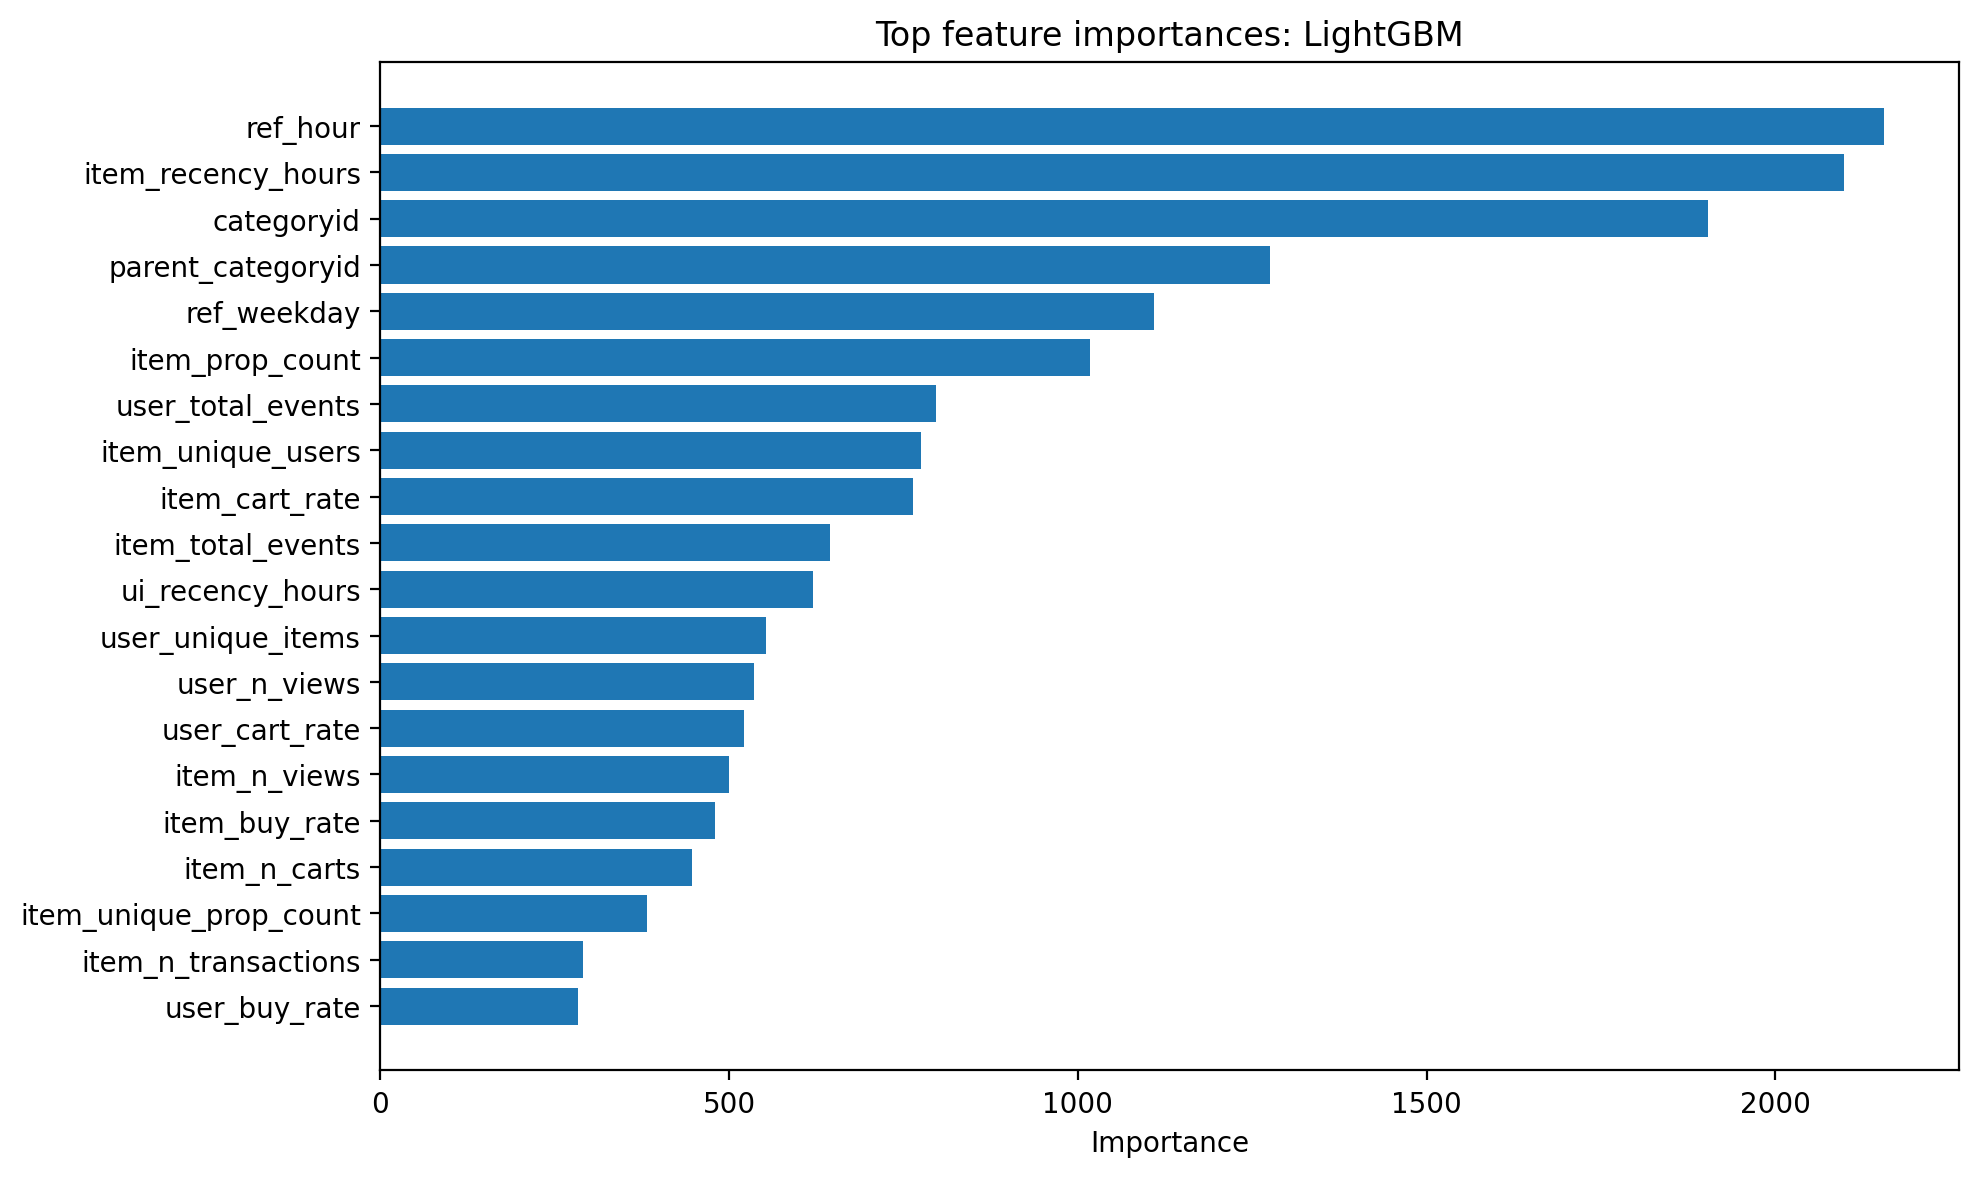

In [74]:
top_n = 20
plot_df = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top feature importances: LightGBM")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9.10 Сохраняем модель

In [75]:
lgbm_model_path = MODELS_DIR / "lgbm_ranker.bin"
joblib.dump(lgbm_model, lgbm_model_path)

print(f"Saved model -> {lgbm_model_path.relative_to(PROJECT_ROOT)}")

Saved model -> models/lgbm_ranker.bin


## 9.11 Логируем в MLflow

In [76]:
feature_importance_path = PROCESSED_DIR / "lgbm_feature_importance.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)

with mlflow.start_run(run_name="lightgbm_ranker"):
    mlflow.log_param("model_type", "LightGBMClassifier")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("num_leaves", 63)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("n_features", len(feature_cols))

    mlflow.log_metric("recall_at_10", float(lgbm_metrics["Recall@10"]))
    mlflow.log_metric("map_at_10", float(lgbm_metrics["MAP@10"]))
    mlflow.log_metric("ndcg_at_10", float(lgbm_metrics["NDCG@10"]))
    mlflow.log_metric("hitrate_at_10", float(lgbm_metrics["HitRate@10"]))

    mlflow.log_artifact(str(lgbm_model_path))
    mlflow.log_artifact(str(feature_importance_path))
    mlflow.log_artifact(str(comparison_table_path))

🏃 View run lightgbm_ranker at: http://127.0.0.1:5000/#/experiments/1/runs/588ff1d2351d4bf593e3fb17f8c04e8a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Выводы по сравнению моделей

По итогам экспериментов лучшей моделью среди протестированных оказался ALS:

- ALS показывает максимальные значения по всем ranking-метрикам;
- LightGBM ranker улучшает baseline-модели, но пока уступает ALS;
- User History + Popular заметно превосходит Top Popular, что подтверждает важность персонализации.

Текущая версия LightGBM, вероятно, ограничена:
- качеством candidate pool;
- недостаточной информативностью признаков;
- обучением/валидацией на одном наборе данных (prototype setup).

Таким образом:
- ALS используется как лучший baseline и сильный генератор кандидатов;
- LightGBM требует дальнейшей доработки признаков и более строгой схемы валидации.

## Выводы по важности признаков

Наиболее значимыми признаками для LightGBM оказались:

- временные признаки (`ref_hour`, `ref_weekday`);
- recency-признаки (`item_recency_hours`);
- категориальные признаки товара (`categoryid`, `parent_categoryid`);
- агрегаты по популярности и конверсии товара.

Это показывает, что:
- временной контекст существенно влияет на вероятность взаимодействия;
- товарные характеристики и свежесть активности являются сильными предикторами;
- текущие user-item interaction признаки пока используются моделью слабее ожидаемого.

## Причины возможного отставания LightGBM от ALS:

- слабый/неполный candidate pool;
- недостаточно сильные interaction-признаки;
- отсутствие pairwise/listwise ranking objective;
- prototype-валидация без честного temporal split;
- ALS уже хорошо захватывает collaborative signal, который сложно перебить простыми ручными признаками.